In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.ion()

# **An introduction to matplotlib**

## **The basics**

In [3]:
plt.isinteractive()

True

> **Important note :** The `%matplotlib inline` magic embeds static images of the plot into our notebook. Another common option is the `%matplotlib notebook` magic. It provides a small level of interactivity to the plot by allowing actions such as resizing and zooming, though note that this requires some additional setup if you're using JupyterLab and can lead to some confusing bugs, depending on the code that's running in the notebook.

In [8]:
fb_df = pd.read_csv(
    '../Datasets/fb_2018.csv',
    index_col='date',
    parse_dates=True,
).convert_dtypes('numpy_nullable')

fb_df.dtypes

open      Float64
high      Float64
low       Float64
close     Float64
volume      Int64
dtype: object

In [9]:
fb_df.index.dtype

dtype('<M8[ns]')

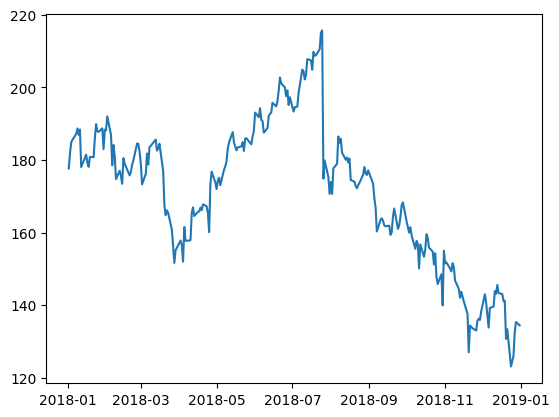

In [10]:
plt.plot(fb_df.index, fb_df.open)

plt.show()

In [14]:
%matplotlib inline

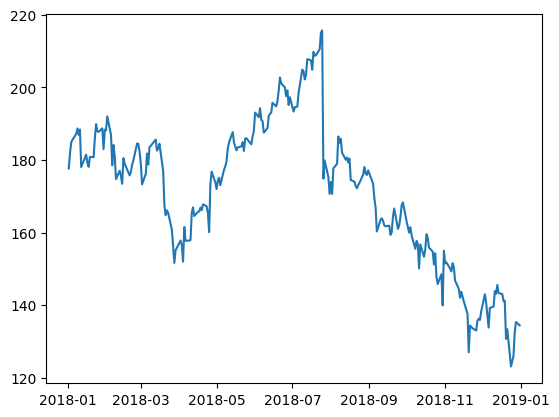

In [16]:
plt.plot(fb_df.index, fb_df.open)

plt.show()

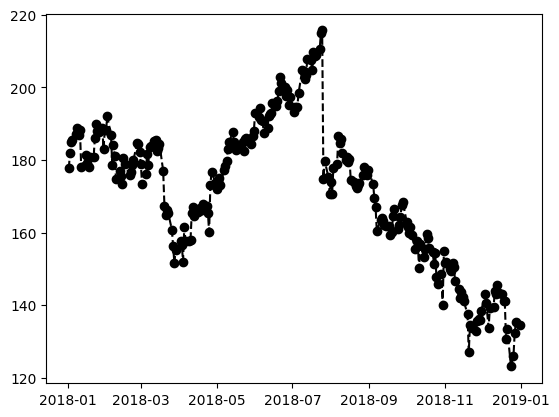

In [23]:
                    # '[marker][linestyle][color]'
plt.plot(fb_df.index, 'open', 'o--k', data=fb_df)

plt.show()

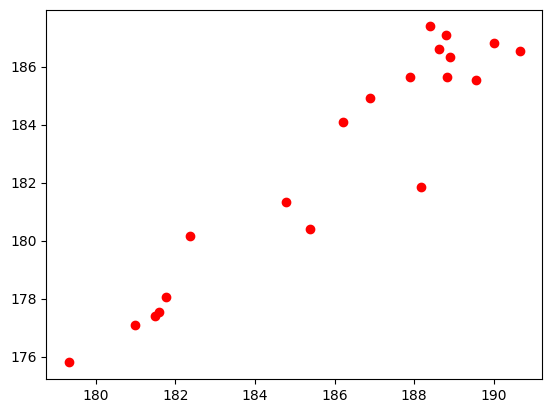

In [25]:
plt.plot('high', 'low', 'or', data=fb_df.head(20))

plt.show()

![Styling shortcuts for matplotlib](../Images/Styling_shortcuts_for_matplotlib.png)

In [26]:
quakes_df = pd.read_csv(
    '../Datasets/earthquakes.csv',
    dtype_backend='numpy_nullable'
)

quakes_df.dtypes

alert      string[python]
cdi               Float64
code       string[python]
detail     string[python]
dmin              Float64
felt              Float64
gap               Float64
ids        string[python]
mag               Float64
magType    string[python]
mmi               Float64
net        string[python]
nst               Float64
place      string[python]
rms               Float64
sig                 Int64
sources    string[python]
status     string[python]
time                Int64
title      string[python]
tsunami             Int64
type       string[python]
types      string[python]
tz                Float64
updated             Int64
url        string[python]
dtype: object

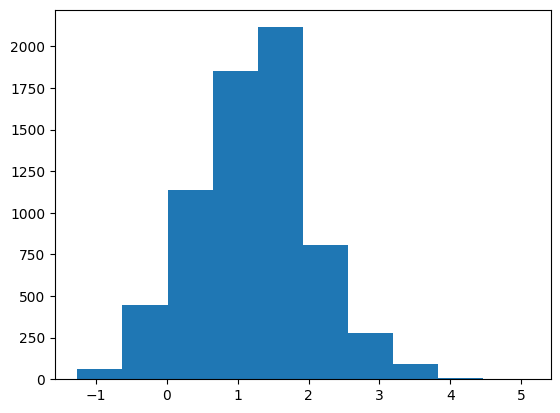

In [28]:
plt.hist(quakes_df.query('magType == "ml"').mag)

plt.show()

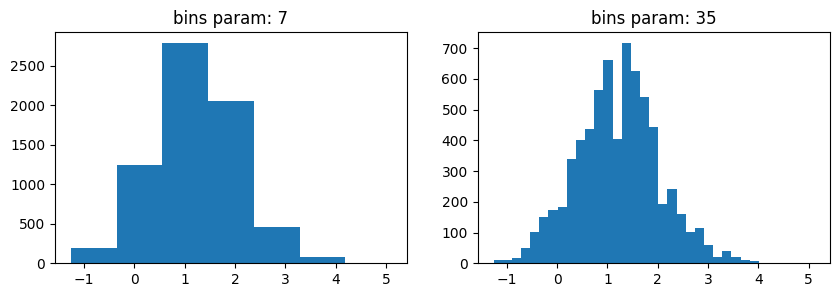

In [32]:
x = quakes_df.query('magType == "ml"').mag

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

for ax, bins in zip(axes, [7, 35]):
    ax.hist(x, bins=bins)
    ax.set_title(f"bins param: {bins}")

plt.show()

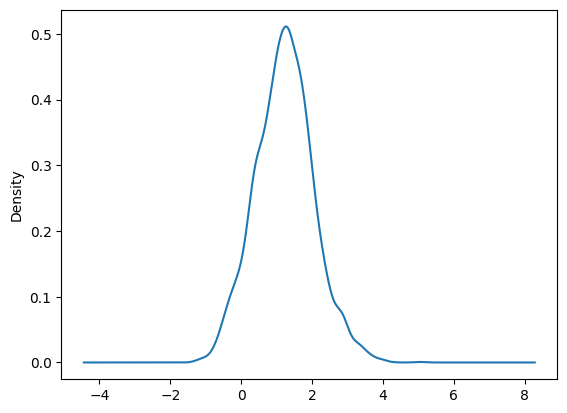

In [35]:
x.plot(kind='kde')

plt.show()

## **Plot components**

In [36]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

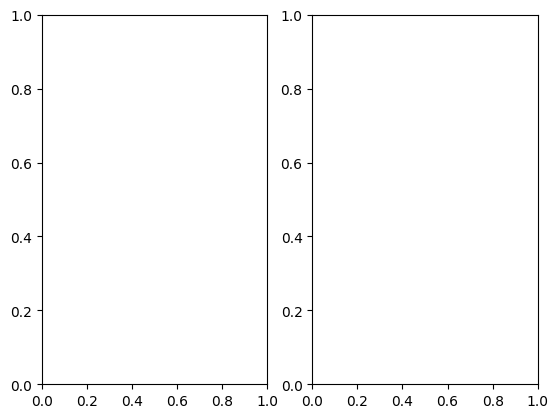

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2)

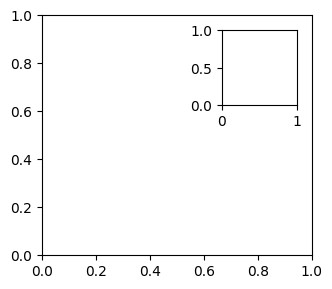

In [42]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.8])
inside = fig.add_axes([0.7, 0.6, 0.25, 0.25])

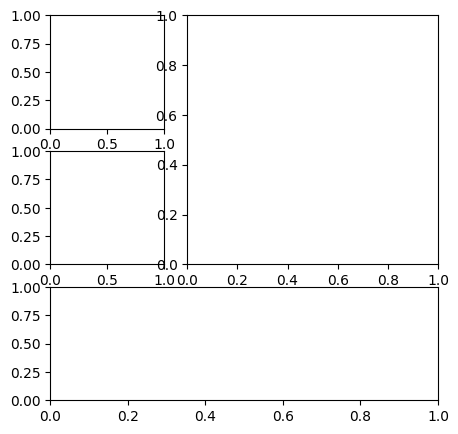

In [46]:
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(nrows=3, ncols=3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2, :])

In [47]:
fig.savefig("empty_figure.png")

In [48]:
plt.close('all')

## **Additional options**

In [49]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

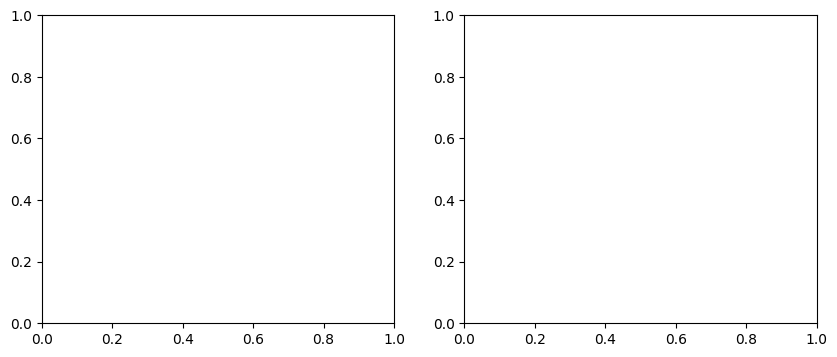

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

In [58]:
import random
import matplotlib as mpl

In [64]:
rcparams_list = list(mpl.rcParams.keys())
random.seed(20)
random.shuffle(rcparams_list)

sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

In [66]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [68]:
mpl.rcParams['figure.figsize'] = (300, 10)

mpl.rcParams['figure.figsize']

[300.0, 10.0]

In [69]:
mpl.rcdefaults()

mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [70]:
mpl.rc('figure', figsize=(20, 20))

mpl.rcParams['figure.figsize']

[20.0, 20.0]

In [71]:
mpl.rcdefaults()

mpl.rcParams['figure.figsize']

[6.4, 4.8]

> **Tip :** If we find ourselves making the same changes every time we start Python, we should look into reading our configuration in rather than updating the default values each time. Consult the `mpl.rc_file()` function for more information.

# **Plotting with pandas**

![Frequently_used_pandas_plotting_arguments](../Images/Frequently_used_pandas_plotting_arguments.png)

In [4]:
fb_df = pd.read_csv(
    '../Datasets/fb_stock_prices_2018.csv',
    index_col='date',
    parse_dates=True
).convert_dtypes("numpy_nullable")

quakes_df = pd.read_csv(
    '../Datasets/earthquakes.csv',
    dtype_backend="numpy_nullable"
)

covid_df = pd.read_csv(
    '../Datasets/covid19_cases.csv',
).assign(
date=lambda x: pd.to_datetime(x.dateRep, format='%d/%m/%Y')
).set_index('date').replace(
    'United_States_of_America', 'USA'
).sort_index()['2020-01-18':'2020-09-18'].convert_dtypes("numpy_nullable")

## **Evolution over time**

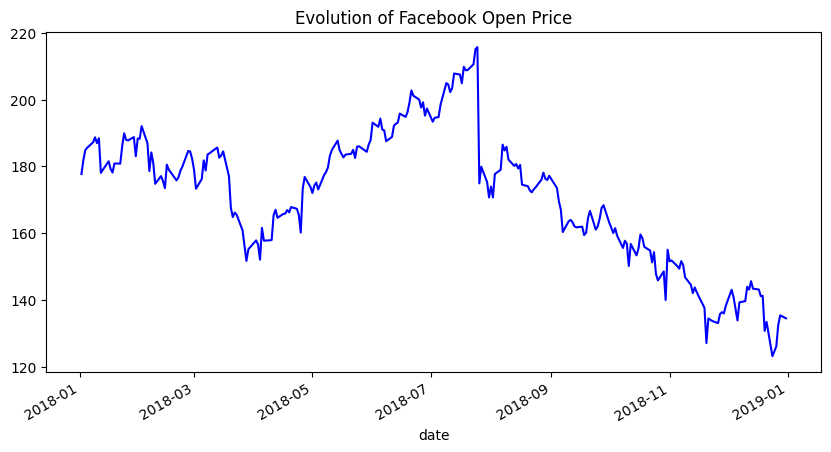

In [84]:
fb_df.plot(
    # kind='line', by defualt is a line plot
    figsize=(10, 5),
    y='open',
    style='-b',
    legend=False,
    title='Evolution of Facebook Open Price'
)

plt.show()

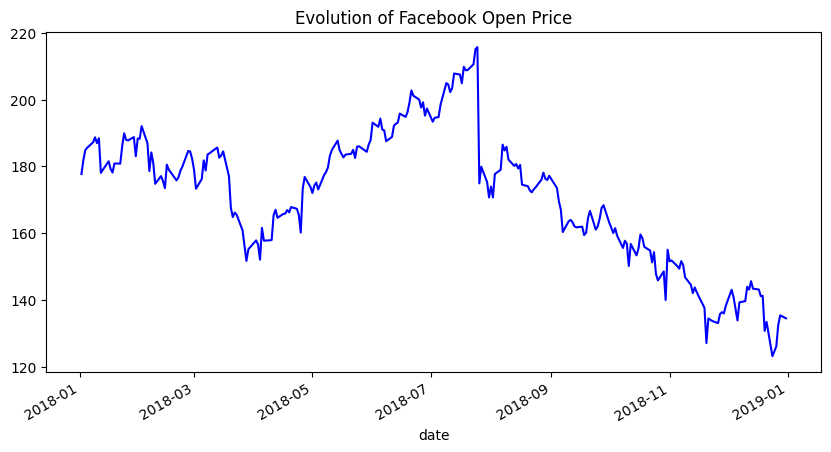

In [86]:
fb_df.plot(
    figsize=(10, 5),
    y='open',
    color='blue',
    linestyle='solid',
    legend=False,
    title='Evolution of Facebook Open Price'
)

plt.show()

/tmp/ipykernel_9329/1819190889.py:1: FutureWarning: first is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  fb_df.first('1W').plot(


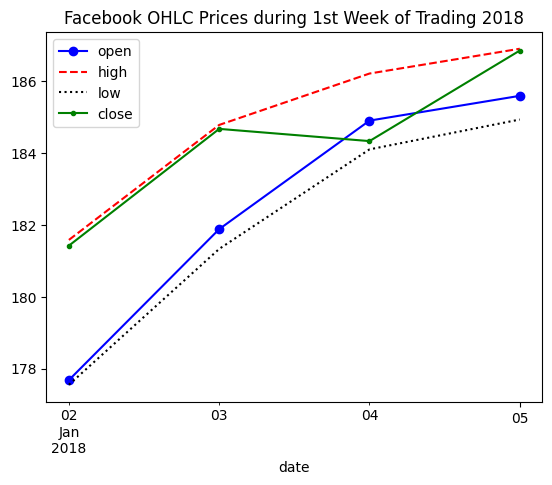

In [90]:
fb_df.first('1W').plot(
    y = ['open', 'high', 'low', 'close'],
    style= ['o-b', '--r', ':k', '.-g'],
    title= 'Facebook OHLC Prices during '
            '1st Week of Trading 2018'
).autoscale() # add space between data and axes

plt.show()

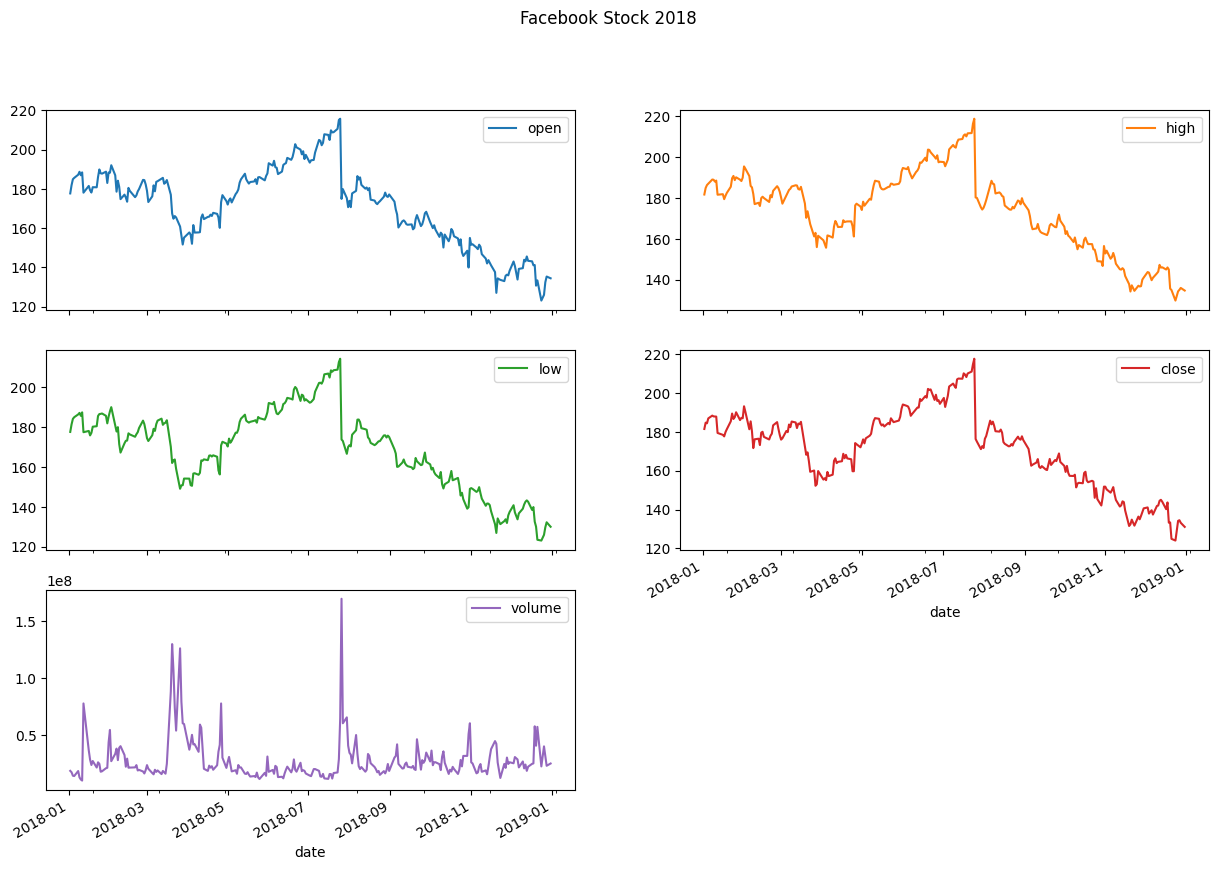

In [93]:
fb_df.plot(
    subplots=True,
    layout=(3, 2),
    figsize=(15, 10),
    title= 'Facebook Stock 2018'
)

plt.show()

In [97]:
new_cases_rolling_average = covid_df.pivot_table(
    index=covid_df.index, 
    columns='countriesAndTerritories', 
    values='cases'
).rolling(7).mean()

new_cases_rolling_average

countriesAndTerritories,Afghanistan,Albania,Algeria,Andorra,Angola,Anguilla,Antigua_and_Barbuda,Argentina,Armenia,Aruba,...,United_Republic_of_Tanzania,United_States_Virgin_Islands,Uruguay,Uzbekistan,Venezuela,Vietnam,Western_Sahara,Yemen,Zambia,Zimbabwe
date,,,,,,,,,,,,,,,,,,,,,
2020-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-14,45.428571,156.857143,270.000000,18.428571,57.142857,0.0,0.0,10667.857143,154.142857,85.285714,...,0.0,5.571429,18.428571,549.285714,1035.857143,2.000000,0.0,3.714286,109.000000,78.428571
2020-09-15,45.857143,159.142857,263.285714,25.285714,60.428571,0.0,0.0,10963.571429,160.571429,82.571429,...,0.0,4.428571,17.000000,583.571429,1031.285714,2.000000,0.0,3.142857,126.285714,33.285714
2020-09-16,47.857143,159.857143,256.571429,25.285714,65.428571,0.0,0.0,11062.571429,166.571429,80.428571,...,0.0,5.857143,16.428571,602.714286,1013.142857,1.285714,0.0,3.142857,123.857143,26.857143


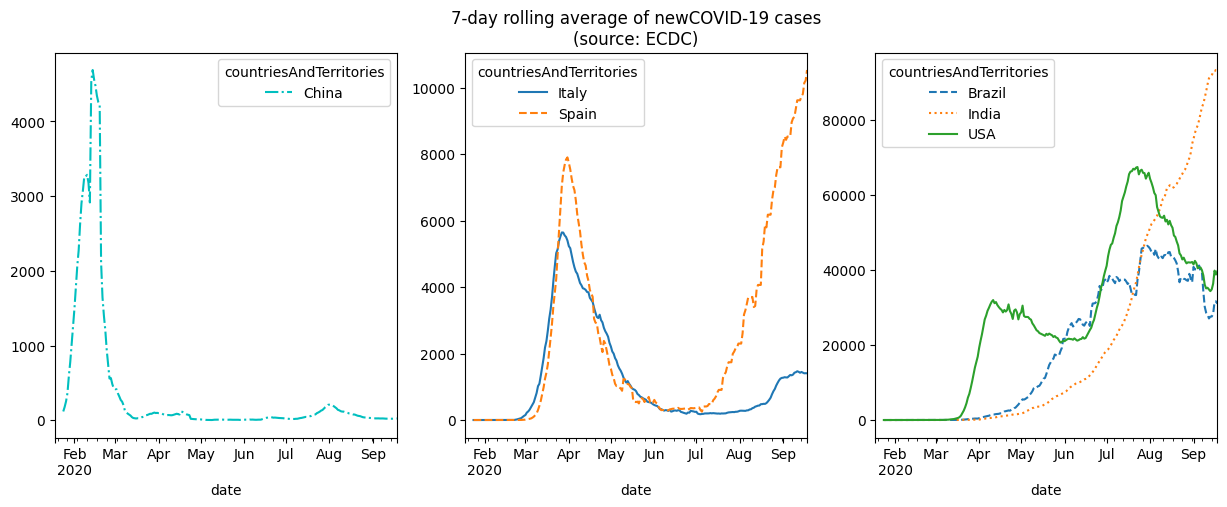

In [104]:
fir, axes = plt.subplots(1, 3, figsize=(15, 5))

new_cases_rolling_average[['China']].plot(ax=axes[0], style='-.c')
new_cases_rolling_average[['Italy', 'Spain']].plot(ax=axes[1], style=['-', '--'], title='7-day rolling average of new'
                                                   'COVID-19 cases\n(source: ECDC)')
new_cases_rolling_average[['Brazil', 'India', 'USA']].plot(ax=axes[2], style=['--', ':', '-'])

plt.show()

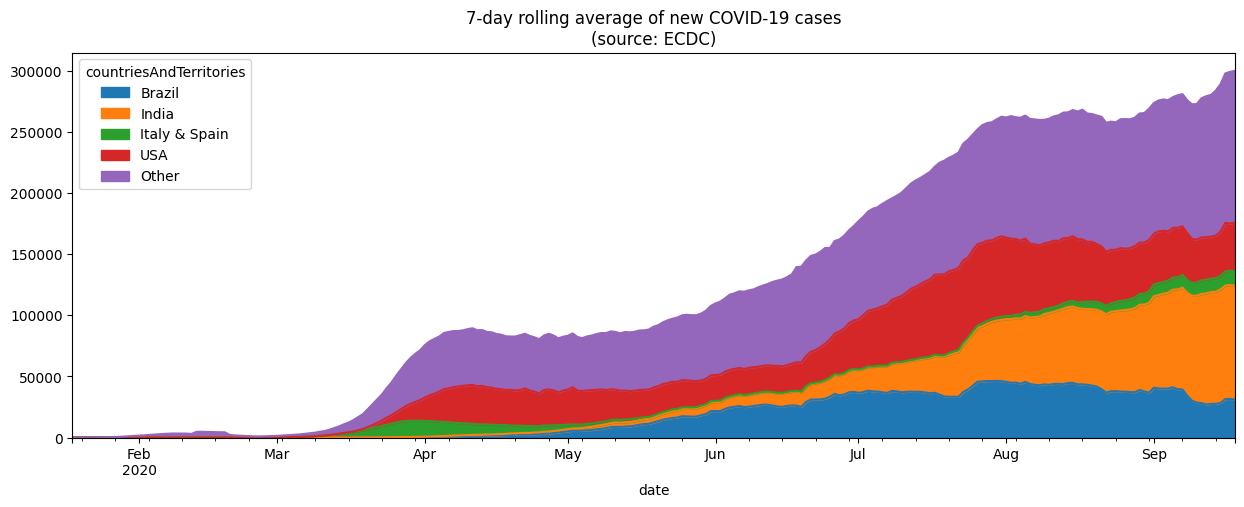

In [116]:
cols = [col for col in new_cases_rolling_average.columns 
        if col not in ['USA', 'Brazil', 'India', 'Italy & Spain']]

new_cases_rolling_average.assign(
    **{'Italy & Spain': lambda x: x.Italy + x.Spain}
).sort_index(axis=1).assign(
    Other= lambda x: x[cols].sum(axis=1)
).drop(columns=cols).plot(
    kind='area',
    figsize=(15, 5),
    title= '7-day rolling average of new '
            'COVID-19 cases\n(source: ECDC)',
    #stacked=False
)

plt.show()

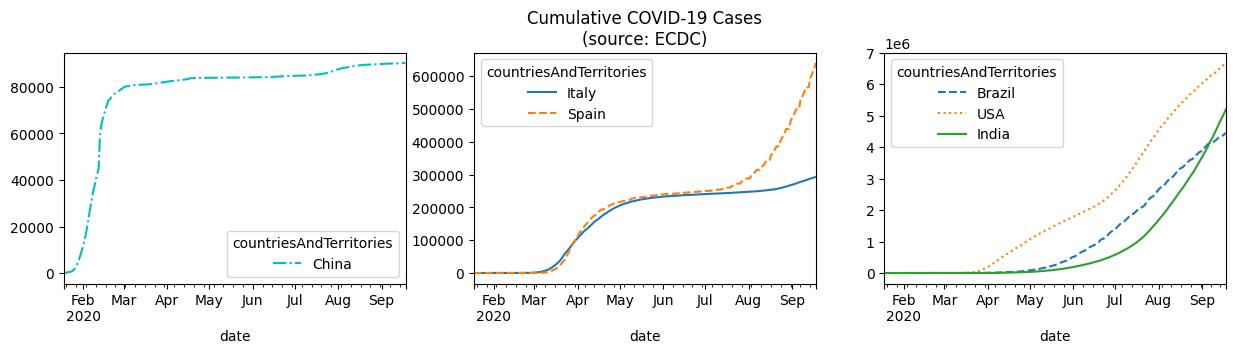

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

cumulative_covid_cases = covid_df\
                                .groupby(['countriesAndTerritories', pd.Grouper(freq='1D')]) \
                                .cases \
                                .sum() \
                                .unstack(0) \
                                .apply('cumsum')

cumulative_covid_cases[['China']].plot(ax=axes[0], style='-.c')
cumulative_covid_cases[['Italy', 'Spain']].plot(
    ax=axes[1], 
    style=['-', '--'], 
    title='Cumulative COVID-19 Cases\n(source: ECDC)')
cumulative_covid_cases[['Brazil', 'USA', 'India']].plot(ax=axes[2], style=['--', ':', '-'])

plt.show()

## **Relationships between variables**

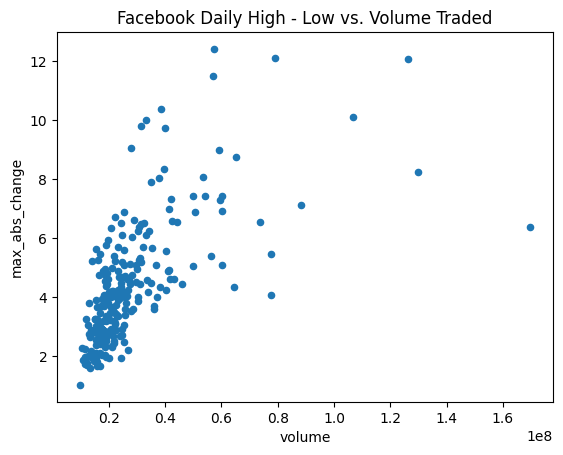

In [127]:
fb_df.assign(
    max_abs_change = fb_df.high - fb_df.low
).plot(
    kind='scatter',
    x='volume',
    y='max_abs_change',
    title='Facebook Daily High - Low vs. Volume Traded'
)

plt.show()

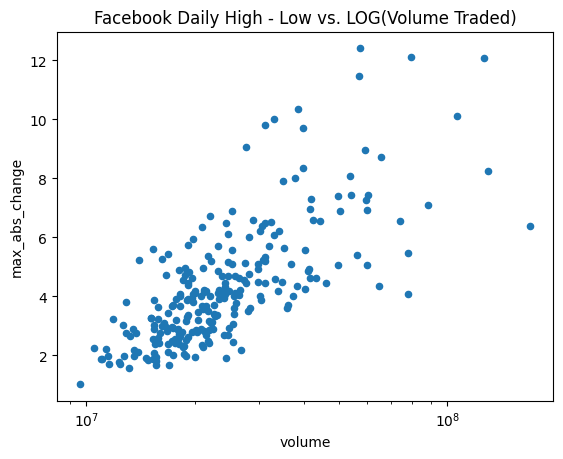

In [130]:
fb_df.assign(
    max_abs_change= fb_df.high - fb_df.low
).plot(
    kind='scatter',
    x='volume',
    y='max_abs_change',
    title='Facebook Daily High - Low vs. LOG(Volume Traded)',
    logx=True
)

plt.show()

> **Tip :**The `plot()` method from pandas has three arguments for logarithmic scales: `logx/logy` for single axis adjustments and `loglog` for setting both to the logarithmic scale.

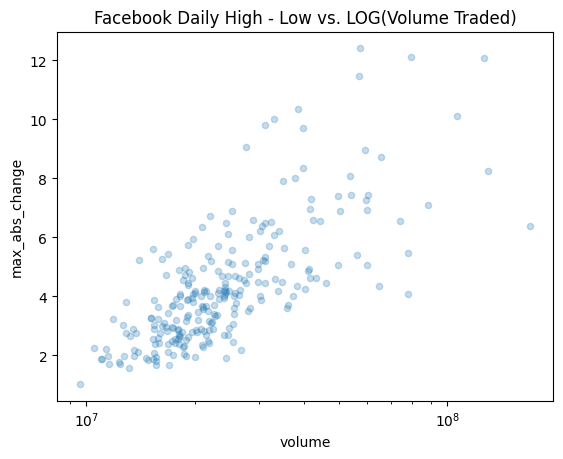

In [134]:
fb_df.assign(
    max_abs_change= fb_df.high - fb_df.low
).plot(
    kind='scatter',
    x='volume',
    y='max_abs_change',
    title='Facebook Daily High - Low vs. LOG(Volume Traded)',
    logx=True,
    alpha=0.25
)

plt.show()

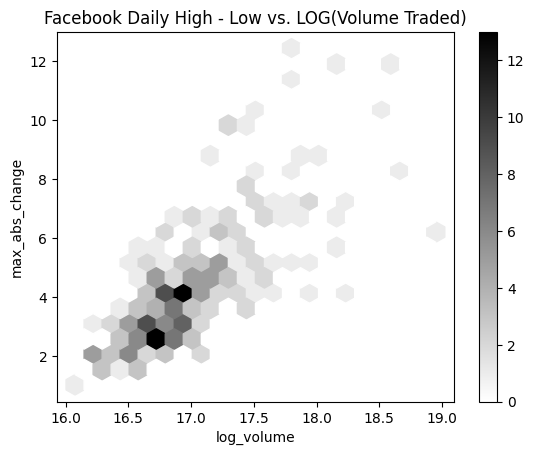

In [142]:
fb_df.assign(
    log_volume = np.log(fb_df.volume),
    max_abs_change = fb_df.high - fb_df.low
).plot(
    kind='hexbin',
    x='log_volume',
    y='max_abs_change',
    title='Facebook Daily High - Low vs. LOG(Volume Traded)',
    colormap='gray_r',
    gridsize=20,
    sharex=False # bug fix to keep the x-axis label
)

plt.show()

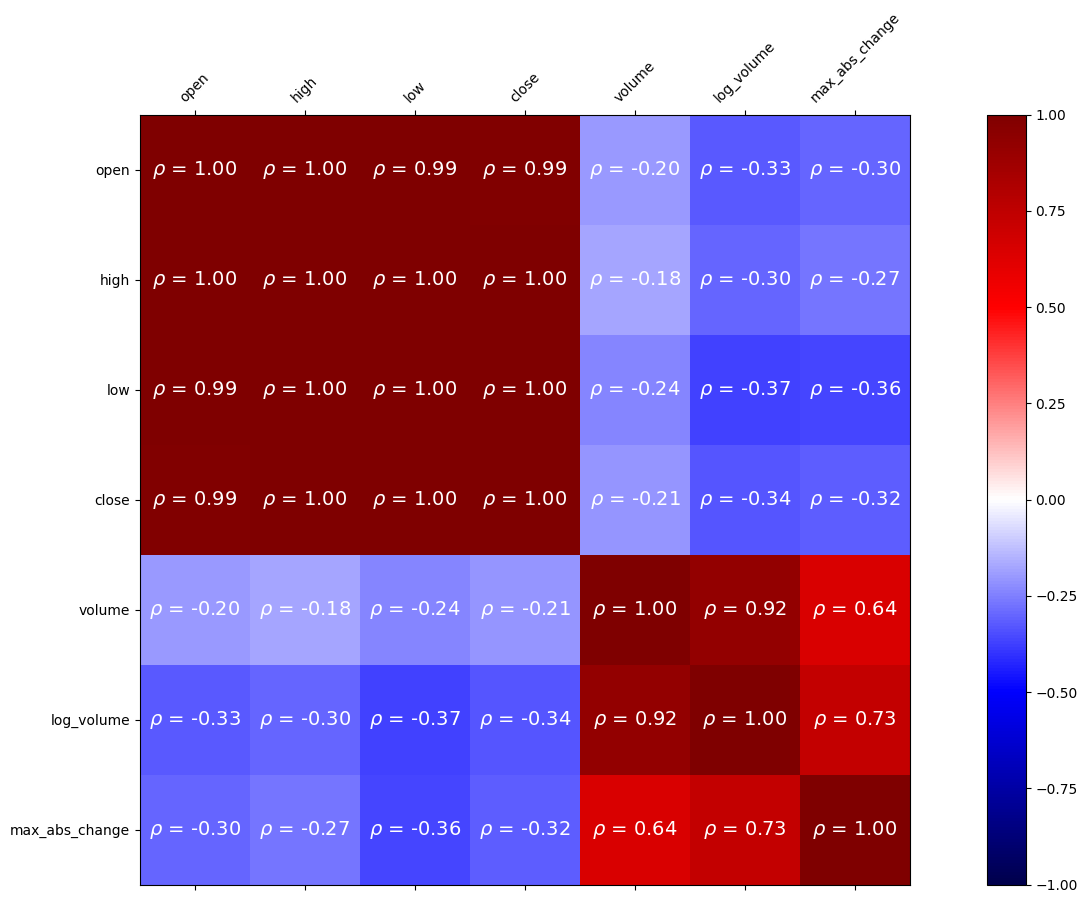

In [164]:
fig, ax = plt.subplots(figsize=(20, 10))

# calculate the correlation matrix
fb_df_corr = fb_df.assign(
    log_volume = np.log(fb_df.volume),
    max_abs_change = fb_df.high - fb_df.low
).corr()

# create the heatmap and colorbar
im = ax.matshow(fb_df_corr, cmap='seismic')
im.set_clim(-1, 1)
fig.colorbar(im)

# label the ticks with the column names
labels = [col.lower() for col in fb_df_corr.columns]
ax.set_xticks(ax.get_xticks()[1:-1])
ax.set_xticklabels(labels, rotation=45)
ax.set_yticks(ax.get_yticks()[1:-1])
ax.set_yticklabels(labels)


# include the value of the correlation coefficient in the boxes
for (i, j), coef in np.ndenumerate(fb_df_corr):
    ax.text(
        i, j, fr'$\rho$ = {coef:.2f}',
        ha='center', va='center',
        color='white', fontsize=14
    )


plt.show()

## **Distributions**

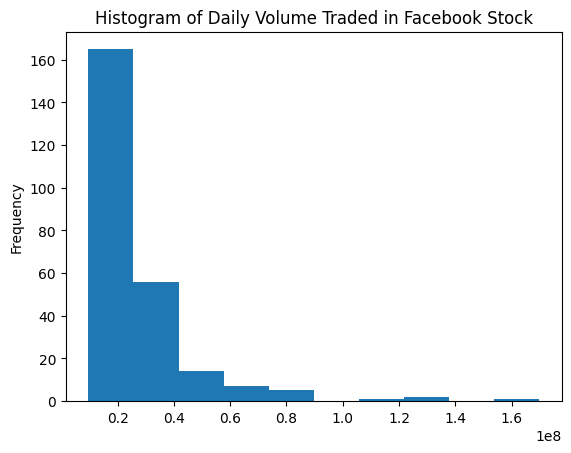

In [167]:
fb_df.volume.plot(
    kind='hist',
    title='Histogram of Daily Volume Traded '
          'in Facebook Stock'
)

plt.show()

> **Tip :** As with the `plt.hist()` function from matplotlib, we can provide a custom value for the number of bins with the bins argument. However, we must be careful that we don't misrepresent the distribution.

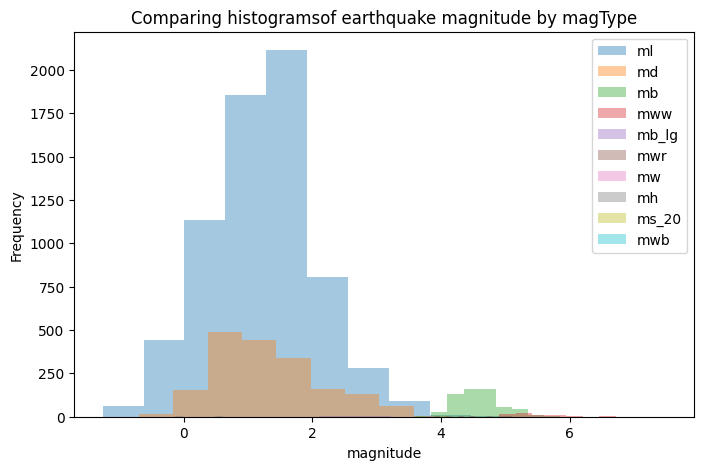

In [173]:
fig, axes = plt.subplots(figsize=(8, 5))

for magtype in quakes_df.magType.unique():
    data = quakes_df.query(f'magType == "{magtype}"').mag
    if not data.empty:
        data.plot(
            kind='hist',
            ax=axes,
            alpha=0.4,
            label=magtype,
            legend=True,
            title='Comparing histograms'
                  'of earthquake magnitude by magType',
        )
plt.xlabel('magnitude')

plt.show()

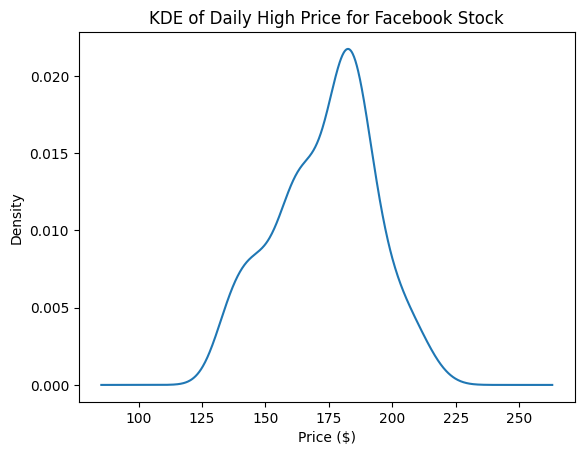

In [179]:
fb_df.high.plot(
    kind='kde',
    title='KDE of Daily High Price for Facebook Stock'
)

plt.xlabel('Price ($)')
plt.show()

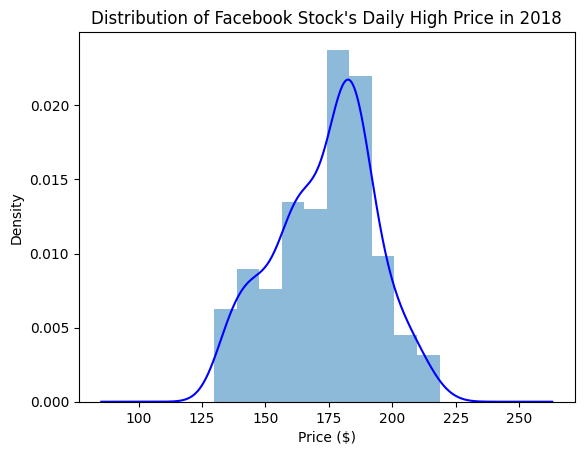

In [182]:
ax = fb_df.high.plot(kind='hist', density=True, alpha=0.5)
fb_df.high.plot(
    kind='kde',
    ax=ax,
    color='blue',
    title='Distribution of Facebook Stock\'s '
          'Daily High Price in 2018'
)

plt.xlabel('Price ($)')
plt.show()

- The **KDE** shows us an estimated **probability density function (PDF)**, which tells us how probability is distributed over the values of the data. However, in some cases, we are more interested in the probability of getting less than or equal to (or greater than or equal to) some value, which we can see with the **cumulative distribution function (CDF)**.

> **Important note :** With a **`CDF`**, the values for the x variable go along the x-axis, while the cumulative probability of getting, at most, a given x goes along the y-axis. This cumulative probability is between 0 and 1 and is written as P(X ≤ x), where the lowercase (x) is the value for comparison and the uppercase (X) is the random variable, X. More information can be found at https://www.itl.nist.gov/div898/handbook/eda/section3/eda362.htm.

In [5]:
from statsmodels.distributions.empirical_distribution import ECDF

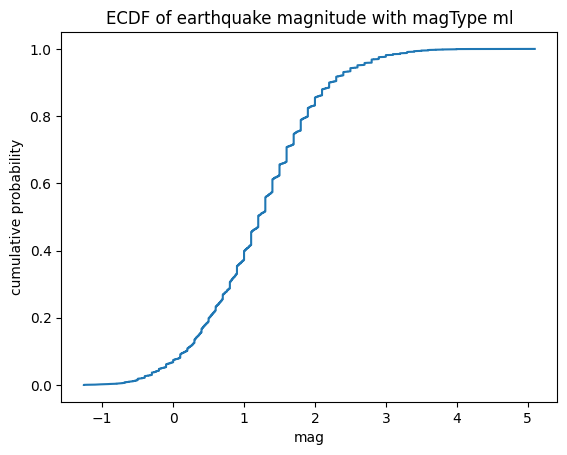

In [8]:
ecdf = ECDF(quakes_df.query('magType == "ml"').mag)

plt.plot(ecdf.x, ecdf.y)
plt.xlabel('mag')
plt.ylabel('cumulative probability')
plt.title('ECDF of earthquake magnitude with magType ml')

plt.show()

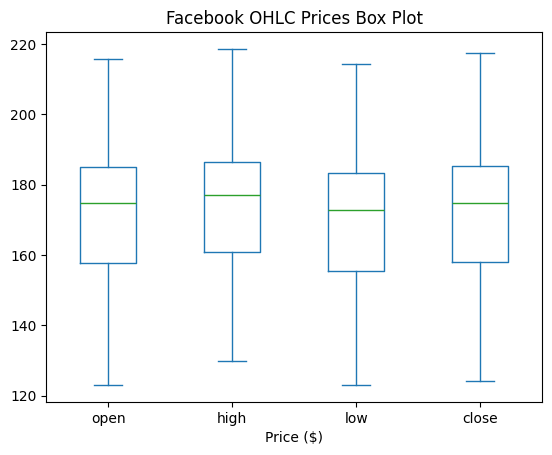

In [9]:
fb_df.iloc[:, :4].plot(
    kind='box',
    title='Facebook OHLC Prices Box Plot'
)
plt.xlabel('Price ($)')

plt.show()

> **Tip :** We can create a **`notched`** box plot by passing in **`notch=True`**. The notch marks a 95% confidence interval around the median, which can be helpful when comparing differences between groups.

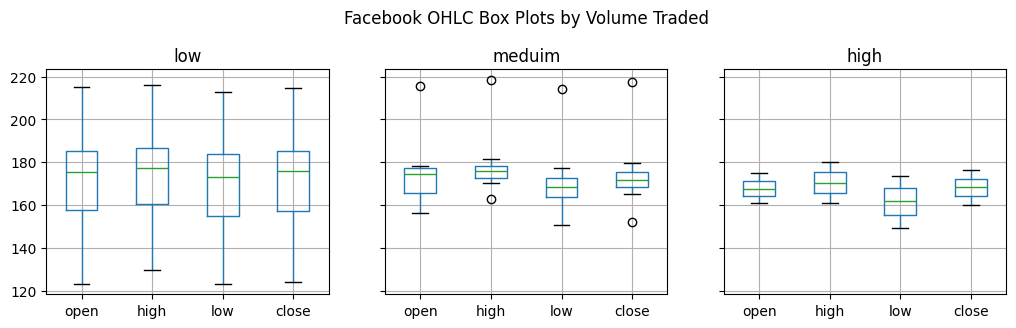

In [14]:
fb_df.assign(
    volume_bin = pd.cut(fb_df.volume, bins=3, labels=['low', 'meduim', 'high'])
).groupby('volume_bin', observed=False).boxplot(
    column=['open', 'high', 'low', 'close'],
    layout=(1, 3), figsize=(12, 3)
)

plt.suptitle('Facebook OHLC Box Plots by Volume Traded', y=1.1)

plt.show()

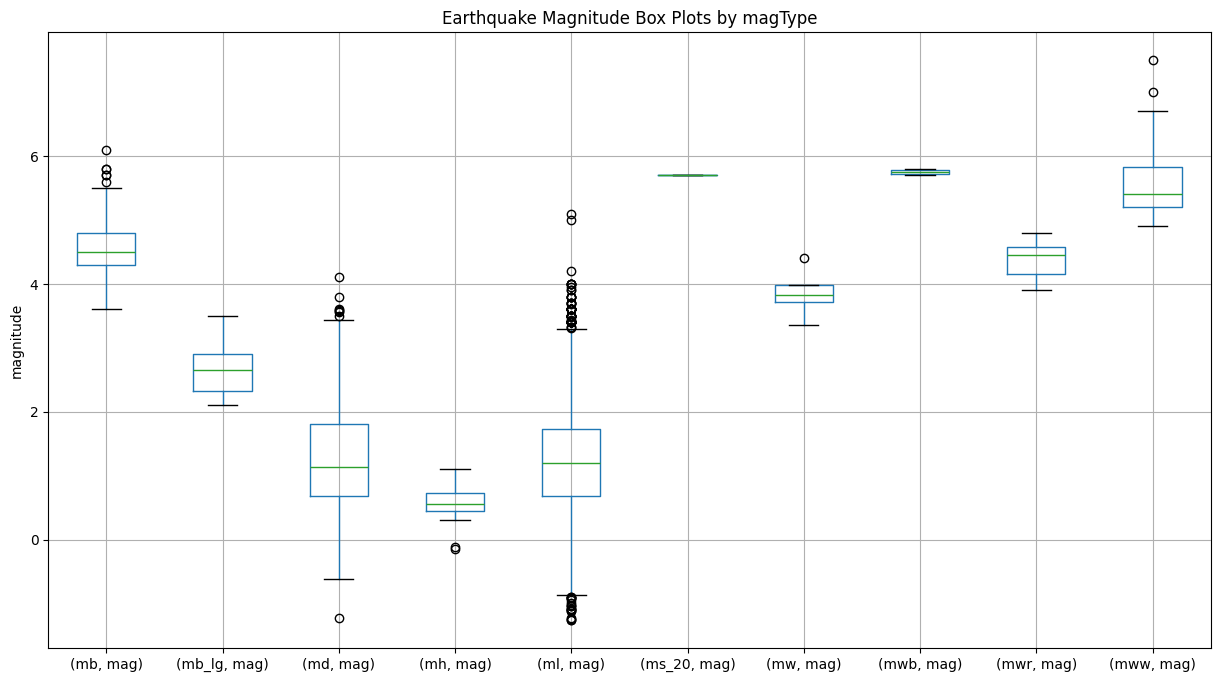

In [17]:
quakes_df[['mag', 'magType']].groupby('magType', observed=False).boxplot(figsize=(15, 8), subplots=False)
plt.title('Earthquake Magnitude Box Plots by magType')
plt.ylabel('magnitude')

plt.show()

> Important note : While **histograms**, **KDEs**, **ECDFs**, and **box plots** are all ways of looking at the distribution of the data, we saw that each visualization showed us a different aspect of it. It's important to visualize the data from many angles before drawing any conclusions.

## **Counts and frequencies**

In [24]:
quakes_dff = pd.read_csv(
    '../Datasets/parsed.csv',
    dtype_backend='numpy_nullable'
)

quakes_dff.dtypes

alert           string[python]
cdi                    Float64
code            string[python]
detail          string[python]
dmin                   Float64
felt                   Float64
gap                    Float64
ids             string[python]
mag                    Float64
magType         string[python]
mmi                    Float64
net             string[python]
nst                    Float64
place           string[python]
rms                    Float64
sig                      Int64
sources         string[python]
status          string[python]
time                     Int64
title           string[python]
tsunami                  Int64
type            string[python]
types           string[python]
tz                     Float64
updated                  Int64
url             string[python]
parsed_place    string[python]
dtype: object

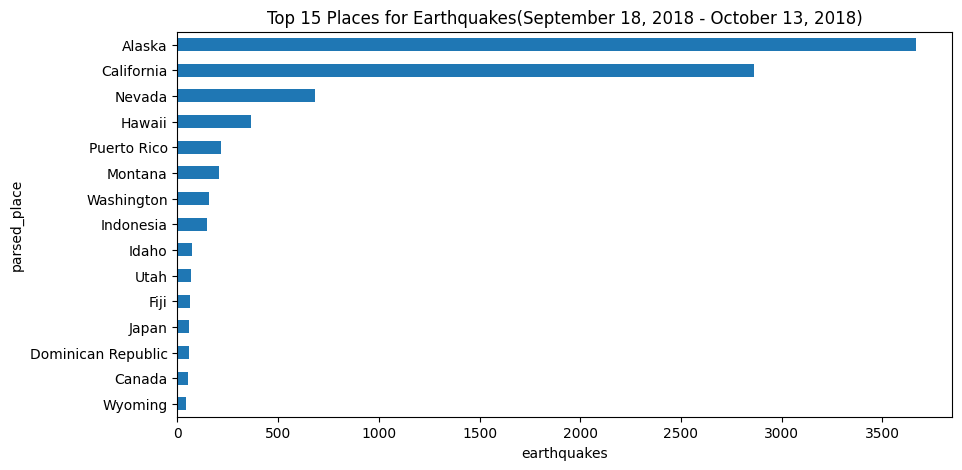

In [29]:
quakes_dff.parsed_place.value_counts().iloc[14::-1, ].plot(
    kind='barh', figsize=(10, 5),
    title='Top 15 Places for Earthquakes'
          '(September 18, 2018 - October 13, 2018)'
)
plt.xlabel('earthquakes')

plt.show()

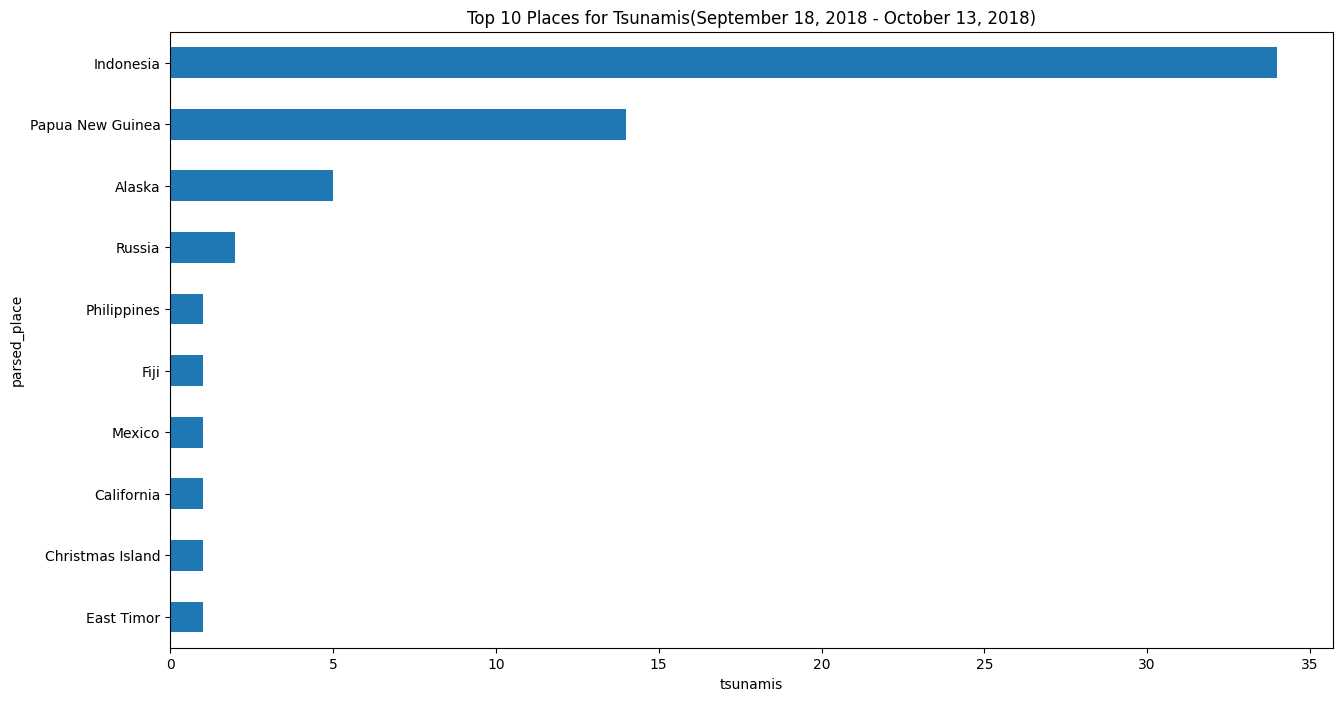

In [33]:
quakes_dff.groupby('parsed_place').tsunami.sum().sort_values().iloc[-10:, ].plot(
    kind='barh', figsize=(15, 8),
    title='Top 10 Places for Tsunamis'
          '(September 18, 2018 - October 13, 2018)'
)
plt.xlabel('tsunamis')

plt.show()

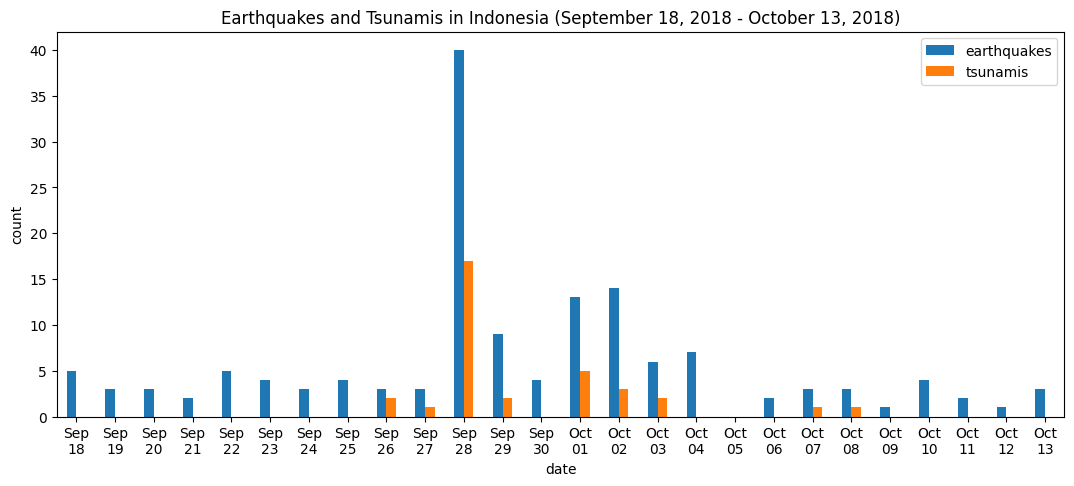

In [38]:
indonesia_quakes = quakes_dff.query(
    'parsed_place == "Indonesia"'
).assign(
    time = lambda x: pd.to_datetime(x.time, unit='ms'),
    earthquake = 1
).set_index('time').resample('1D').sum()

indonesia_quakes.index = indonesia_quakes.index.strftime('%b\n%d')

indonesia_quakes.plot(
    y=['earthquake', 'tsunami'], 
    kind='bar',
    rot=0,
    figsize=(13, 5),
    label=['earthquakes', 'tsunamis'],
    title='Earthquakes and Tsunamis in Indonesia '
          '(September 18, 2018 - October 13, 2018)'
)
plt.xlabel('date')
plt.ylabel('count')

plt.show()

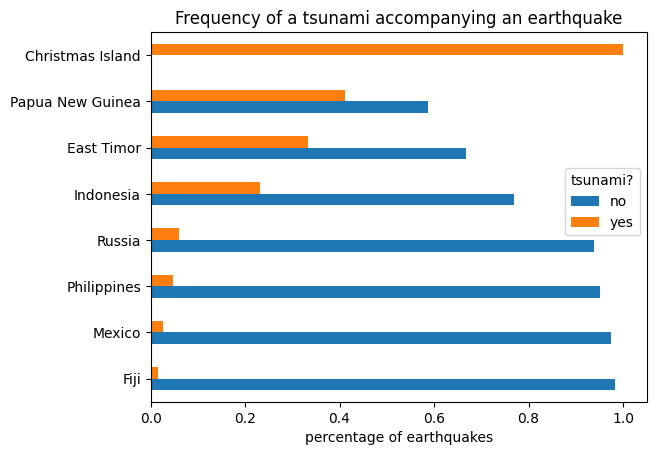

In [48]:
quakes_dff\
    .groupby(['parsed_place', 'tsunami'])\
    .mag\
    .count()\
    .unstack(level=1)\
    .apply(lambda x: x / x.sum(), axis=1)\
    .rename(columns={0: 'no', 1: 'yes'})\
    .sort_values('yes', ascending=False)[7::-1]\
    .plot.barh(
        title='Frequency of a tsunami accompanying an earthquake'
    )
plt.legend(title='tsunami?', bbox_to_anchor=(1, 0.65))
plt.xlabel('percentage of earthquakes')
plt.ylabel('')

plt.show()

> **Tip :** When saving the preceding plots, long category names may get cut off; if that's the case, try running **`plt.tight_layout()`** before saving.

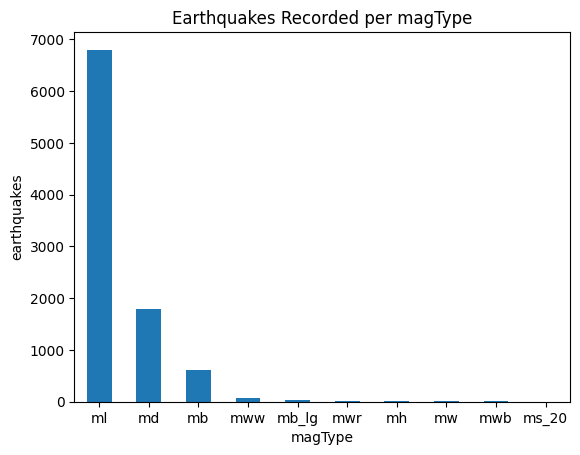

In [50]:
quakes_dff.magType.value_counts().plot(
    kind='bar', rot=0,
    title='Earthquakes Recorded per magType'
)
plt.xlabel('magType')
plt.ylabel('earthquakes')

plt.show()

In [51]:
pivot = quakes_dff.assign(
    mag_bin= lambda x: np.floor(x.mag)
).pivot_table(
    index='mag_bin',
    columns='magType',
    values='mag',
    aggfunc='count'
)

pivot

magType,mb,mb_lg,md,mh,ml,ms_20,mw,mwb,mwr,mww
mag_bin,,,,,,,,,,
-2.0,<NA>,<NA>,1,<NA>,13,<NA>,<NA>,<NA>,<NA>,<NA>
-1.0,<NA>,<NA>,29,2,446,<NA>,<NA>,<NA>,<NA>,<NA>
0.0,<NA>,<NA>,721,9,2072,<NA>,<NA>,<NA>,<NA>,<NA>
1.0,<NA>,<NA>,700,1,3126,<NA>,<NA>,<NA>,<NA>,<NA>
2.0,<NA>,25,267,<NA>,985,<NA>,<NA>,<NA>,<NA>,<NA>
3.0,7,5,77,<NA>,153,<NA>,3,<NA>,2,<NA>
4.0,514,<NA>,1,<NA>,6,<NA>,1,<NA>,12,2
5.0,79,<NA>,<NA>,<NA>,2,1,<NA>,2,<NA>,55
6.0,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9


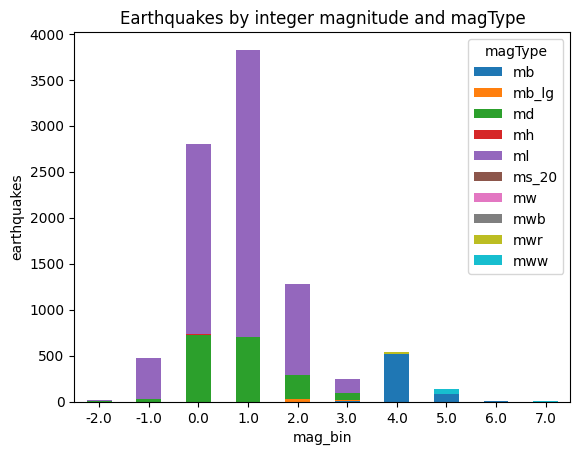

In [53]:
pivot.plot.bar(
    rot=0,
    stacked=True,
    title='Earthquakes by integer magnitude and magType'
)
plt.ylabel('earthquakes')

plt.show()

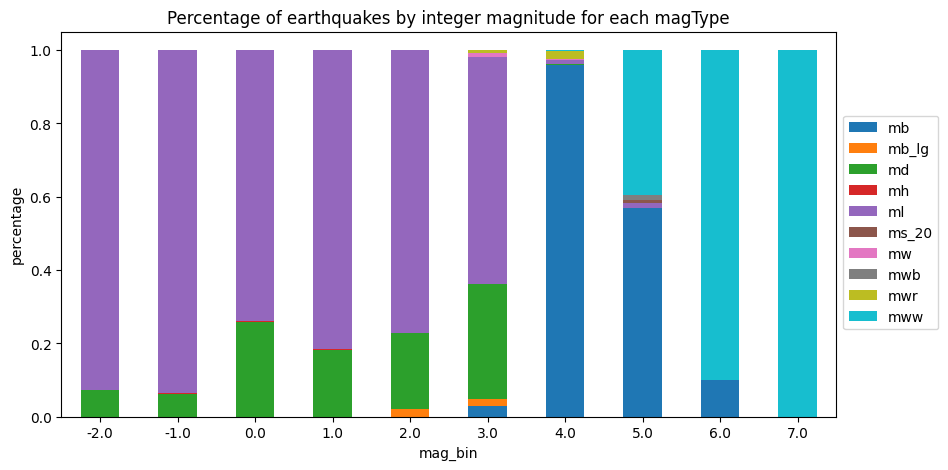

In [57]:
normalized_pivot = pivot.fillna(0).apply(lambda x: x / x.sum(), axis=1)

ax = normalized_pivot.plot.bar(
    stacked=True, rot=0, figsize=(10, 5),
    title='Percentage of earthquakes by integer magnitude for each magType'
)
ax.legend(bbox_to_anchor=(1, 0.8))
plt.ylabel('percentage')

plt.show()

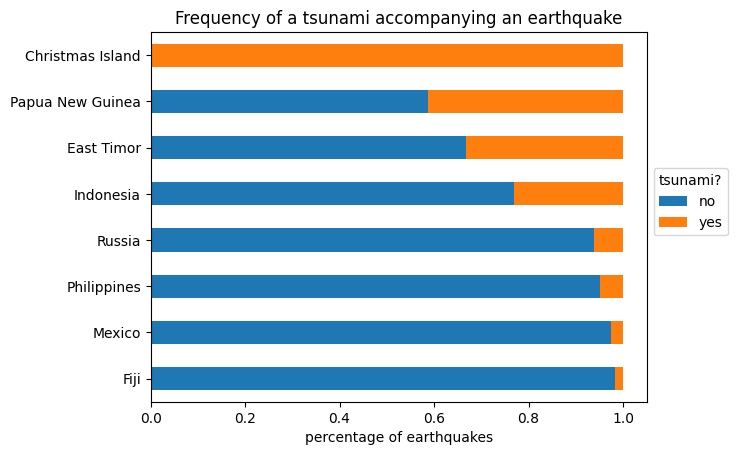

In [58]:
quakes_dff.groupby(['parsed_place', 'tsunami']).mag.count()\
    .unstack().apply(lambda x: x / x.sum(), axis=1)\
    .rename(columns={0: 'no', 1: 'yes'})\
    .sort_values('yes', ascending=False)[7::-1]\
    .plot.barh(
        title='Frequency of a tsunami accompanying an earthquake',
        stacked=True
)
# move legend to the right of the plot
plt.legend(title='tsunami?', bbox_to_anchor=(1, 0.65))
plt.xlabel('percentage of earthquakes')
plt.ylabel('')

plt.show()

# **The `pandas.plotting` module**

In [4]:
%matplotlib inline

In [8]:
fb_df = pd.read_csv(
    '../Datasets/fb_stock_prices_2018.csv',
    index_col='date',
    parse_dates=True
).convert_dtypes('numpy_nullable')

fb_df.head()

,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.55,181.42,18151903
2018-01-03,181.88,184.78,181.33,184.67,16886563
2018-01-04,184.9,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.9,184.93,186.85,13574535
2018-01-08,187.2,188.9,186.33,188.28,17994726


## **Scatter matrices**

In [9]:
from pandas.plotting import scatter_matrix

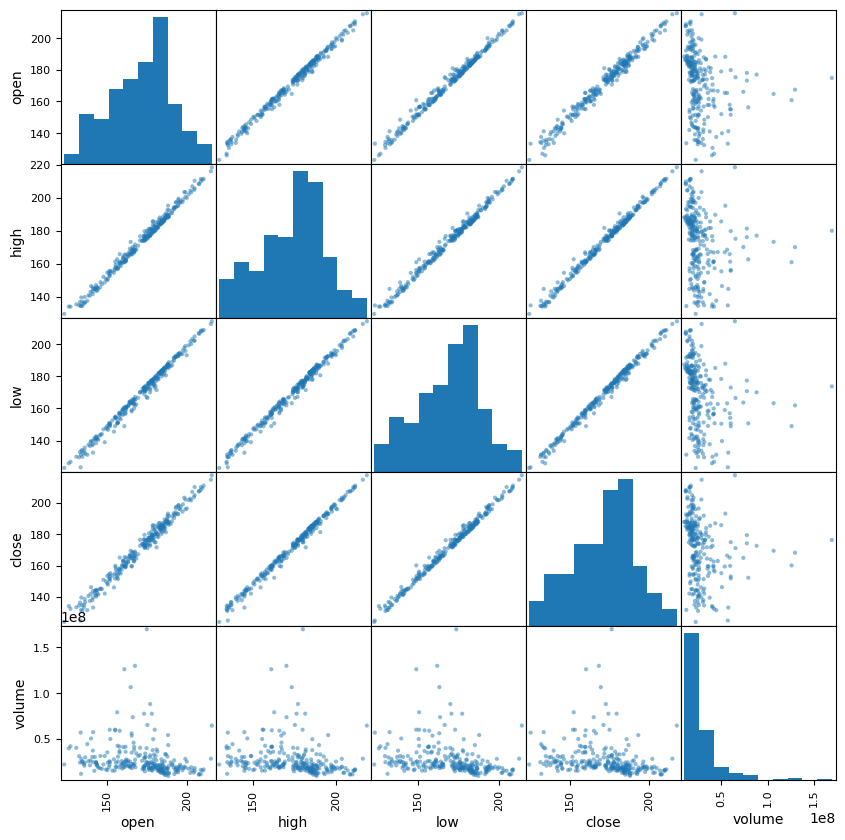

In [11]:
scatter_matrix(fb_df, figsize=(10, 10))

plt.show()

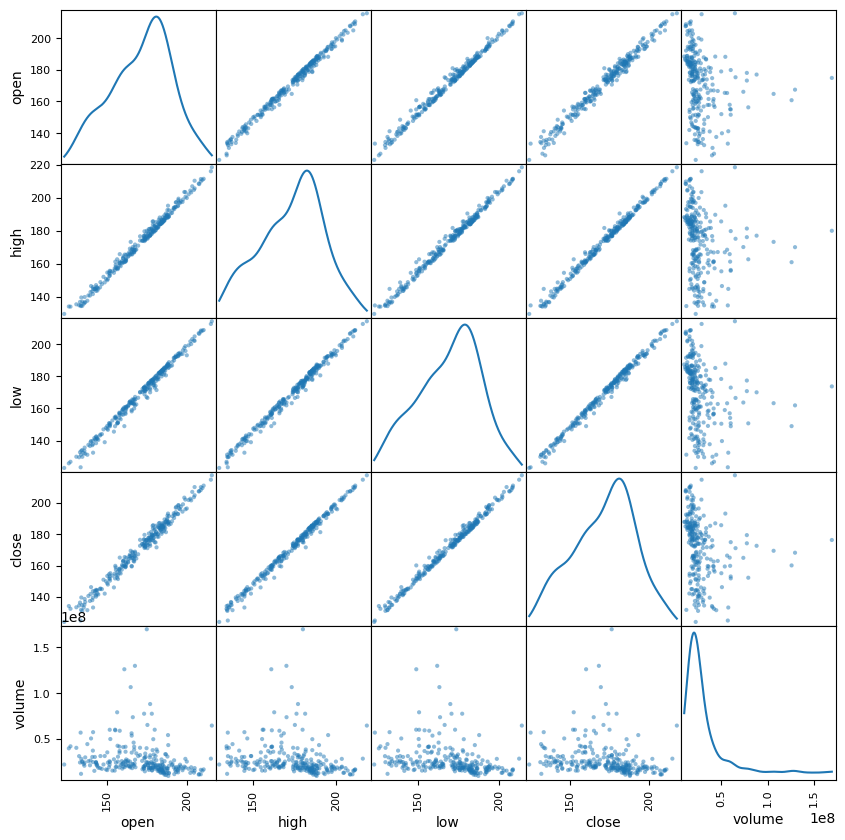

In [12]:
scatter_matrix(fb_df, figsize=(10, 10), diagonal='kde')

plt.show()

## **Lag plots**

In [13]:
from pandas.plotting import lag_plot

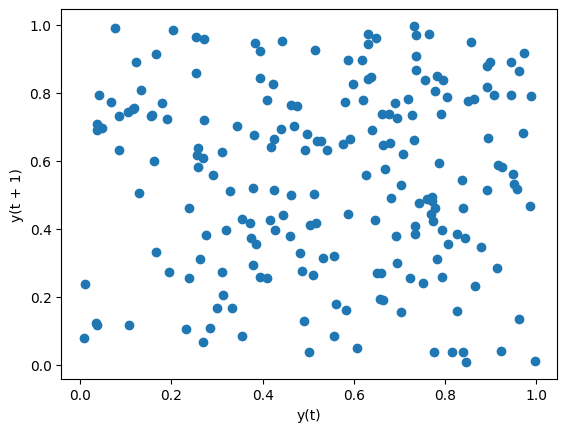

In [15]:
np.random.seed(20)
lag_plot(pd.Series(np.random.random(size=200)))

plt.show()

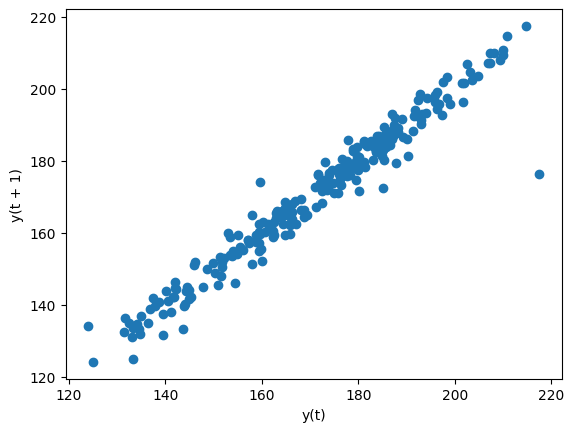

In [16]:
lag_plot(fb_df.close)

plt.show()

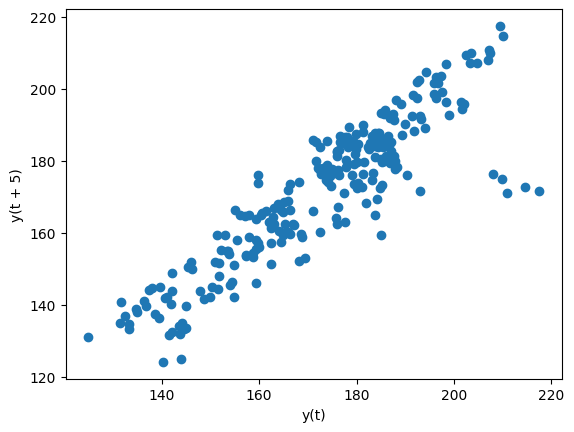

In [17]:
lag_plot(fb_df.close, lag=5)

plt.show()

## **Autocorrelation plots**

In [18]:
from pandas.plotting import autocorrelation_plot

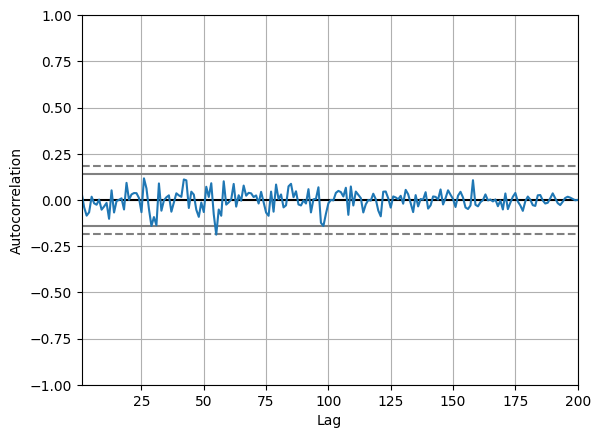

In [19]:
np.random.seed(42)
autocorrelation_plot(pd.Series(np.random.random(size=200)))

plt.show()

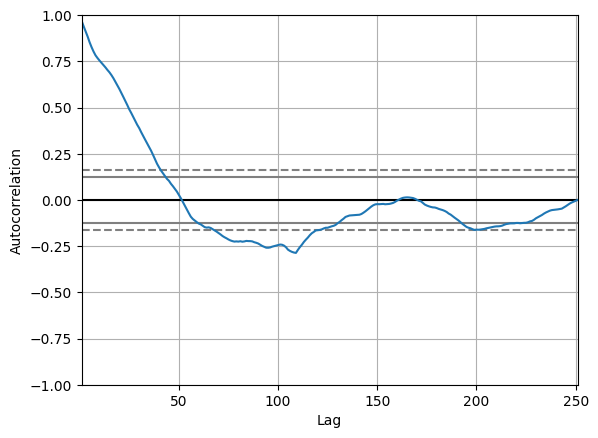

In [20]:
autocorrelation_plot(fb_df.close)

plt.show()

## **Bootstrap plots**

In [21]:
from pandas.plotting import bootstrap_plot

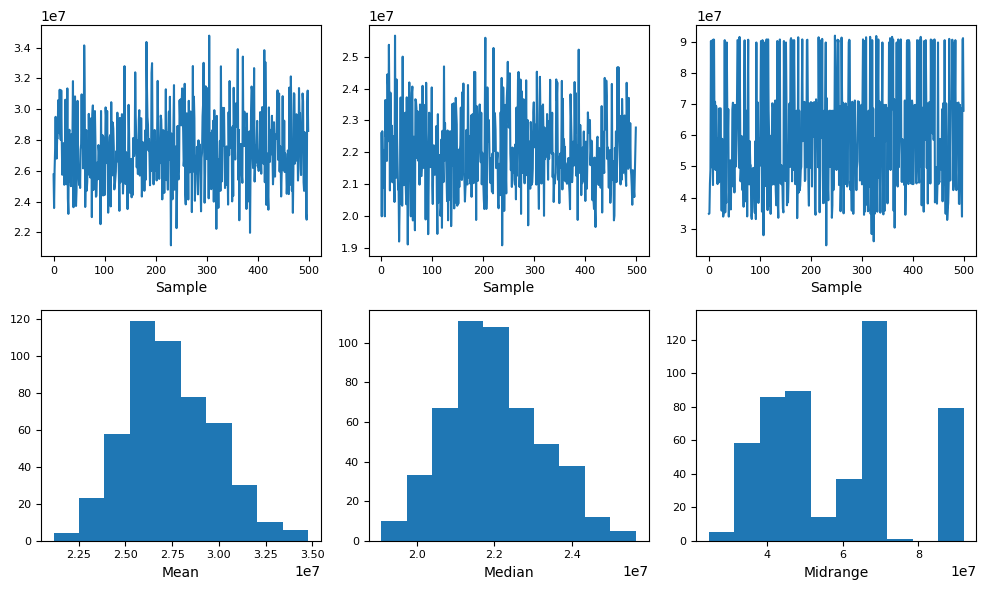

In [23]:
fig = bootstrap_plot(
    fb_df.volume, fig=plt.figure(figsize=(10, 6))
)

plt.show()

# **Further reading**

- **Bootstrapping (statistics):** https://en.wikipedia.org/wiki/Bootstrapping_ (statistics)
- **Data Visualization – Best Practices and Foundations:** https://www.toptal.com/designers/data-visualization/data-visualization-best-practices
- **How to Create Animated Graphs in Python (with matplotlib):** https://towardsdatascience.com/how-to-create-animated-graphs-in-python-bb619cc2dec1
- **Interactive Plots with JavaScript (D3.js):** https://d3js.org/
- **Intro to Animations in Python (with plotly):** https://plot.ly/python/animations/
- **IPython: Built-in magic commands:** https://ipython.readthedocs.io/en/stable/interactive/magics.html
- **The Importance of Integrity: How Plot Parameters Influence Interpretation:** https://www.t4g.com/insights/plot-parameters-influence-interpretation/
- **5 Python Libraries for Creating Interactive Plots:** https://mode.com/blog/python-interactive-plot-libraries/